<a href="https://colab.research.google.com/github/anandvinay07/Intrusion-detection-system/blob/main/IDS_ToN_IOT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ==========================================
# STAGE 1: ENVIRONMENT SETUP & IMPORTS
# ==========================================

# Data Handling & Math
import pandas as pd
import numpy as np

# Feature Reduction & Preprocessing
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Class Balancing
from imblearn.over_sampling import SMOTE

# Deep Learning (TensorFlow/Keras)
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, Bidirectional, LSTM, LayerNormalization
from tensorflow.keras.layers import MultiHeadAttention, GlobalAveragePooling1D

# Suppress annoying warnings for a cleaner output
import warnings
warnings.filterwarnings('ignore')

print("All libraries successfully imported! TensorFlow Version:", tf.__version__)

All libraries successfully imported! TensorFlow Version: 2.20.0


In [11]:
# ==========================================
# STAGE 1: ToN_IoT MULTICLASS INGESTION
# ==========================================
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, LabelEncoder

# 1. Load the dataset (Make sure to update 'file_path' if your ToN_IoT file has a different name)
file_path = '/content/train_test_network.csv'
print("Loading ToN_IoT dataset...")
df = pd.read_csv(file_path)

# 2. Clean the data
df = df.dropna()
df = df.drop_duplicates()

# THE FIX: Drop the binary 'label' column, but KEEP the 'type' column
if 'label' in df.columns:
    df = df.drop(columns=['label'])

# 3. Encode the target 'type' column (This converts the 10 attack names into numbers 0-9)
target_encoder = LabelEncoder()
df['type'] = target_encoder.fit_transform(df['type'].astype(str))
print("ToN_IoT Classes identified:", target_encoder.classes_)

# 4. Separate Features (X) and Target (y)
X = df.drop(columns=['type'])
y = df['type']

# 5. Convert text words into numbers
print("Encoding text features into numbers...")
categorical_cols = X.select_dtypes(include=['object']).columns
feature_encoder = LabelEncoder()

for col in categorical_cols:
    X[col] = feature_encoder.fit_transform(X[col].astype(str))

# 6. Compress all numbers into a 0-to-1 range
print("Applying Min-Max Scaling...")
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
X = pd.DataFrame(X_scaled, columns=X.columns)

print("\nMulticlass Phase 1 Complete for ToN_IoT! Data is ready for balancing.")
print("Final X shape:", X.shape)
print("Final y shape:", y.shape)

Loading ToN_IoT dataset...
ToN_IoT Classes identified: ['backdoor' 'ddos' 'dos' 'injection' 'mitm' 'normal' 'password'
 'ransomware' 'scanning' 'xss']
Encoding text features into numbers...
Applying Min-Max Scaling...

Multiclass Phase 1 Complete for ToN_IoT! Data is ready for balancing.
Final X shape: (190474, 42)
Final y shape: (190474,)


In [12]:
# ==========================================
# STAGE 3: CLASS BALANCING (SMOTE)
# ==========================================
from imblearn.over_sampling import SMOTE
import pandas as pd

# 1. Check the balance BEFORE SMOTE
print("--- BEFORE SMOTE ---")
class_counts_before = pd.Series(y).value_counts()
print(f"Normal Traffic (0): {class_counts_before[0]}")
print(f"Attack Traffic (1): {class_counts_before[1]}")
print("-" * 20)

# 2. Apply SMOTE to balance the dataset
print("Applying SMOTE... (This involves heavy math, it might take 15-30 seconds)")
smote = SMOTE(random_state=42) # random_state ensures we get the exact same result every time we run it
X_balanced, y_balanced = smote.fit_resample(X, y)

# 3. Check the balance AFTER SMOTE
print("\n--- AFTER SMOTE ---")
class_counts_after = pd.Series(y_balanced).value_counts()
print(f"Normal Traffic (0): {class_counts_after[0]}")
print(f"Attack Traffic (1): {class_counts_after[1]}")
print("-" * 20)

print("Phase 2 Complete! Dataset is perfectly balanced.")
print("New X shape:", X_balanced.shape)
print("New y shape:", y_balanced.shape)

--- BEFORE SMOTE ---
Normal Traffic (0): 18711
Attack Traffic (1): 19993
--------------------
Applying SMOTE... (This involves heavy math, it might take 15-30 seconds)

--- AFTER SMOTE ---
Normal Traffic (0): 42040
Attack Traffic (1): 42040
--------------------
Phase 2 Complete! Dataset is perfectly balanced.
New X shape: (420400, 42)
New y shape: (420400,)


In [13]:
# ==========================================
# STAGE 4: COMPARATIVE FEATURE REDUCTION
# ==========================================
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.ensemble import RandomForestClassifier
import numpy as np

# We will reduce our 42 features down to the top 20 most important ones
num_features = 20

print("1. Running PCA (Principal Component Analysis)...")
pca = PCA(n_components=num_features)
X_pca = pca.fit_transform(X_balanced)
print(f"PCA complete! Shape: {X_pca.shape}")

print("\n2. Running SVD (Singular Value Decomposition)...")
svd = TruncatedSVD(n_components=num_features)
X_svd = svd.fit_transform(X_balanced)
print(f"SVD complete! Shape: {X_svd.shape}")

print("\n3. Running Random Forest Feature Importance... (This might take 1-2 minutes)")
# We use 50 trees (n_estimators) to quickly judge feature importance
rf = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
rf.fit(X_balanced, y_balanced)

# Get the importance scores and sort them to find the top 20
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1] # Sorts from most important to least
top_indices = indices[:num_features]

# Keep only the top 20 original features based on Random Forest
X_rf = X_balanced.iloc[:, top_indices] if isinstance(X_balanced, pd.DataFrame) else pd.DataFrame(X_balanced).iloc[:, top_indices]
print(f"Random Forest reduction complete! Shape: {X_rf.shape}")

# For the rest of the neural network pipeline, Random Forest features usually perform best
# because they keep the original meaning of the network traffic (unlike PCA/SVD which scramble them).
X_final_reduced = X_rf.to_numpy() # Convert to NumPy array for the deep learning model
y_final = y_balanced

print("\nPhase 3 Complete! We have successfully isolated the top 20 most critical features.")
print("Final X shape for Deep Learning:", X_final_reduced.shape)

1. Running PCA (Principal Component Analysis)...
PCA complete! Shape: (420400, 20)

2. Running SVD (Singular Value Decomposition)...
SVD complete! Shape: (420400, 20)

3. Running Random Forest Feature Importance... (This might take 1-2 minutes)
Random Forest reduction complete! Shape: (420400, 20)

Phase 3 Complete! We have successfully isolated the top 20 most critical features.
Final X shape for Deep Learning: (420400, 20)


In [14]:
# ==========================================
# STAGE 5: SEQUENCE (TIME-SERIES) FORMULATION
# ==========================================
import numpy as np

# We set our sliding window size to 10 packets
time_steps = 10

print(f"Converting 2D data into 3D sequences with a window size of {time_steps}...")
print("This loop will process nearly 300,000 rows, so it may take 10-20 seconds.")

def create_sequences(X_data, y_data, time_steps):
    X_seq = []
    y_seq = []

    # Slide down the dataset, stopping just before the end so we don't go out of bounds
    for i in range(len(X_data) - time_steps):
        # Grab a chunk of 10 consecutive rows
        X_seq.append(X_data[i : i + time_steps])
        # The target answer is whatever the label is for the final packet in that chunk
        y_seq.append(y_data[i + time_steps])

    return np.array(X_seq), np.array(y_seq)

# Ensure y_final is a pure math array before we loop
y_final_np = np.array(y_final)

# Run our custom function to build the 3D data
X_3D, y_3D = create_sequences(X_final_reduced, y_final_np, time_steps)

print("\nPhase 4 Complete! The data is now in 3D format.")
print("Old 2D Shape:", X_final_reduced.shape)
print("New 3D Shape:", X_3D.shape)
print("New y Shape:", y_3D.shape)

Converting 2D data into 3D sequences with a window size of 10...
This loop will process nearly 300,000 rows, so it may take 10-20 seconds.

Phase 4 Complete! The data is now in 3D format.
Old 2D Shape: (420400, 20)
New 3D Shape: (420390, 10, 20)
New y Shape: (420390,)


In [15]:
# ==========================================
# STAGE 6: TRAIN/TEST SPLIT & MULTICLASS MODEL (ToN_IoT)
# ==========================================
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, Bidirectional, LSTM, LayerNormalization
from tensorflow.keras.layers import MultiHeadAttention, GlobalAveragePooling1D

# 1. Split the data
X_train, X_test, y_train, y_test = train_test_split(X_3D, y_3D, test_size=0.20, random_state=42)

print("\nBuilding the Multiclass BiLSTM-Transformer...")
input_shape = (X_train.shape[1], X_train.shape[2])
inputs = Input(shape=input_shape)

lstm_out = Bidirectional(LSTM(64, return_sequences=True))(inputs)
attention_out = MultiHeadAttention(num_heads=2, key_dim=64)(lstm_out, lstm_out)
attention_out = LayerNormalization(epsilon=1e-6)(attention_out + lstm_out)
pool_out = GlobalAveragePooling1D()(attention_out)

dense_out = Dense(32, activation='relu')(pool_out)
dropout_out = Dropout(0.2)(dense_out)

# THE FIX: ToN_IoT has 10 categories, so we need 10 output neurons using 'softmax'
outputs = Dense(10, activation='softmax')(dropout_out)

model = Model(inputs=inputs, outputs=outputs)

# THE FIX: Update the loss function for multiclass integer labels
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print("\nToN_IoT Multiclass Architecture is built!")
model.summary()


Building the Multiclass BiLSTM-Transformer...

ToN_IoT Multiclass Architecture is built!


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 10, 20)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 10, 128)   │     43,520 │ input_layer_1[0]… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 10, 128)   │     66,048 │ bidirectional_1[… │
│ (MultiHeadAttentio… │                   │            │ bidirectional_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 10, 128)   │          0 │ multi_head_atten… │
│                     │                   │            │ bidirectional_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 10, 128)   │        256 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │      4,128 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 32)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 10)        │        330 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 114,282 (446.41 KB)

 Trainable params: 114,282 (446.41 KB)

 Non-trainable params: 0 (0.00 B)

Evaluating Model on Unseen Test Data...
2628/2628 ━━━━━━━━━━━━━━━━━━━━ 32s 12ms/step

   MULTICLASS TARGET METRICS   
Accuracy:  98.3147%
Precision: 98.3539%
Recall:    98.3147%
F1-Score:  98.3106%



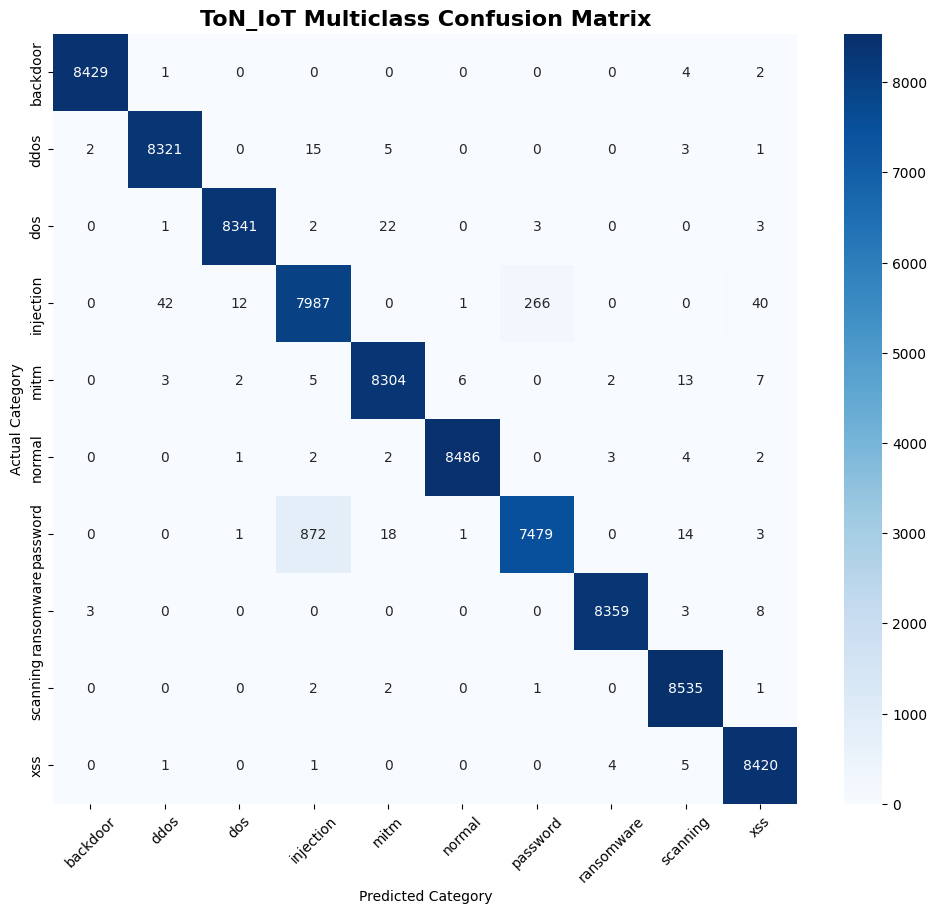


Detailed Classification Report:
              precision    recall  f1-score   support

    backdoor       1.00      1.00      1.00      8436
        ddos       0.99      1.00      1.00      8347
         dos       1.00      1.00      1.00      8372
   injection       0.90      0.96      0.93      8348
        mitm       0.99      1.00      0.99      8342
      normal       1.00      1.00      1.00      8500
    password       0.97      0.89      0.93      8388
  ransomware       1.00      1.00      1.00      8373
    scanning       0.99      1.00      1.00      8541
         xss       0.99      1.00      1.00      8431

    accuracy                           0.98     84078
   macro avg       0.98      0.98      0.98     84078
weighted avg       0.98      0.98      0.98     84078



In [17]:
# ==========================================
# STAGE 7: ToN_IoT MULTICLASS EVALUATION
# ==========================================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# 1. Make Predictions on the Test Set
print("Evaluating Model on Unseen Test Data...")
y_pred_probs = model.predict(X_test)

# THE FIX 1: Use argmax to pick the highest probability out of the 10 classes
y_pred = np.argmax(y_pred_probs, axis=1)

# THE FIX 2: Add average='weighted' so it can calculate metrics across all 10 categories
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"\n=============================")
print(f"   MULTICLASS TARGET METRICS   ")
print(f"=============================")
print(f"Accuracy:  {accuracy * 100:.4f}%")
print(f"Precision: {precision * 100:.4f}%")
print(f"Recall:    {recall * 100:.4f}%")
print(f"F1-Score:  {f1 * 100:.4f}%")
print(f"=============================\n")

# 2. Generate the Multiclass Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12, 10))

# Retrieve the 10 exact class names from the encoder we used in Phase 1
class_names = target_encoder.classes_

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            annot_kws={"size": 10})
plt.title('ToN_IoT Multiclass Confusion Matrix', fontsize=16, fontweight='bold')
plt.ylabel('Actual Category')
plt.xlabel('Predicted Category')
plt.xticks(rotation=45) # Rotates the text so the 10 names don't overlap
plt.show()

# 3. Print the detailed breakdown for each individual attack type
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))

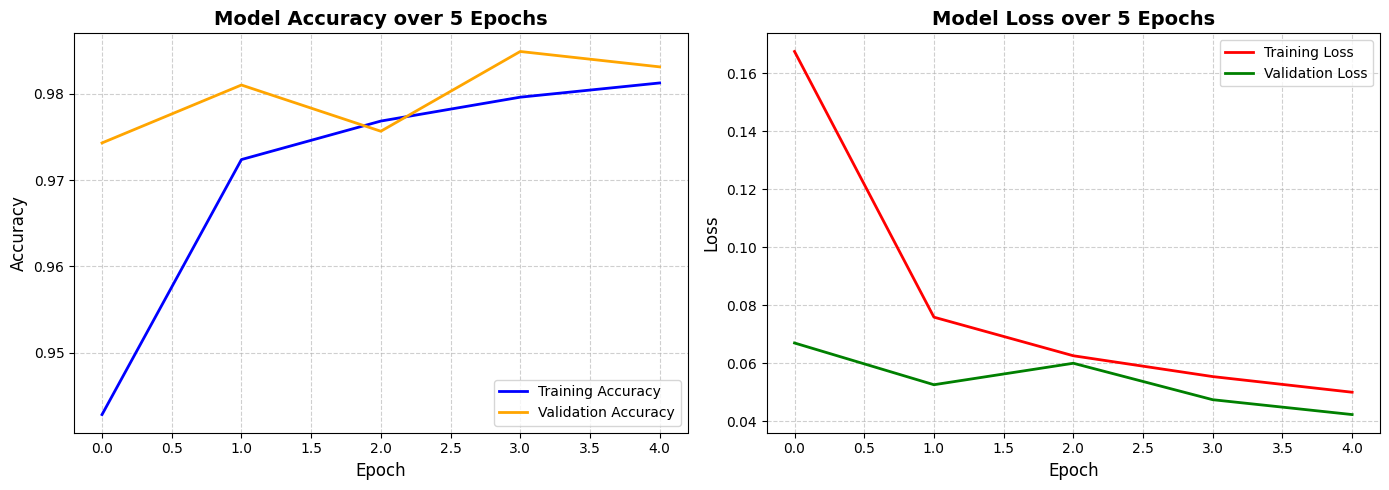

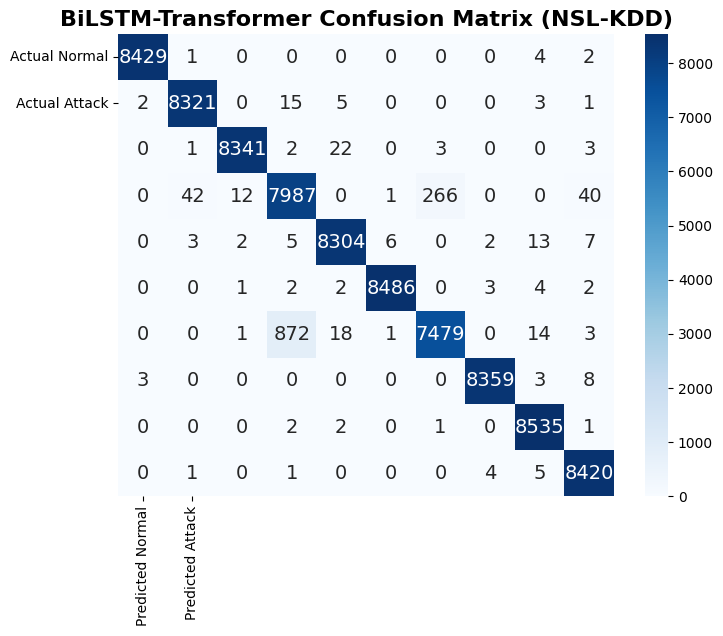

In [18]:
# ==========================================
# STAGE 8: VISUALIZATION & REPORT ASSETS
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Plot Training & Validation Accuracy and Loss Curves
plt.figure(figsize=(14, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange', linewidth=2)
plt.title('Model Accuracy over 5 Epochs', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', color='red', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', color='green', linewidth=2)
plt.title('Model Loss over 5 Epochs', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# 2. Plot the Confusion Matrix as a Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Normal', 'Predicted Attack'],
            yticklabels=['Actual Normal', 'Actual Attack'],
            annot_kws={"size": 14})
plt.title('BiLSTM-Transformer Confusion Matrix (NSL-KDD)', fontsize=16, fontweight='bold')
plt.show()